# Data & AI Job Market — Business Insights
## Notebook 2 — From Descriptive Analysis to Practical Recommendations

Author: Francisco Martinez Grecco  
Project: [Data-ai-jobs-analysis](https://github.com/FranciscoMartinezGrecco/Data-ai-jobs-analysis)  
Previous notebook: `01_eda.ipynb`

## Purpose

The first notebook focused on exploring and understanding the dataset. This notebook goes a step further by analyzing specific questions related to salaries, remote work, company size, and career opportunities in the Data & AI job market.

The analysis is designed for two groups:

- People trying to enter the Data & AI industry and understand which roles or locations offer better opportunities.
- HR or compensation teams looking for salary references and hiring insights.

## Business Questions

1. Remote Work and Salaries — Do remote jobs actually pay more when comparing similar roles and experience levels?
2. Entry-Level Opportunities — Which junior roles provide the best balance between accessibility and salary?
3. Geographic Salary Gaps — How large are salary differences between countries, and how relevant is remote work in reducing those gaps?
4. Company Size and Compensation — Do larger companies consistently offer higher salaries?
5. Salary Growth (2020–2022) — Which roles experienced the strongest salary growth over time?
6. Salary Benchmarks — What salary ranges are common for different combinations of role, experience level, and location?
7. Final Recommendations — A summary of the main findings and practical conclusions from the analysis.

## Methodology

This notebook focuses on comparisons that are as fair as possible by controlling for variables such as role and experience level whenever relevant.

In addition to visual analysis, the notebook includes sample sizes, statistical comparisons, and salary distributions to support the conclusions with data instead of relying only on charts.

---

## Section 1 — Setup and Data Loading

Before starting the analysis, we load the dataset and apply the same cleaning and feature engineering pipeline used in Notebook 1. Reusing the functions from `src/` keeps both notebooks consistent and avoids duplicating logic.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add the parent folder to the path so we can import from src/
import sys
sys.path.append('..')

from src.clean import load_raw_data, clean_salaries_df
from src.features import build_features

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Same style as Notebook 1 to keep visual consistency
sns.set_theme(style='whitegrid', palette='viridis')

print("Imports done.")

Imports done.


In [2]:
# Load and prepare the data using the same pipeline as Notebook 1
df_raw = load_raw_data('../data/raw/ds_salaries.csv')
df = clean_salaries_df(df_raw)
df = build_features(df)

print(f"\nDataset ready: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded 607 rows × 12 columns
Removed 42 duplicate rows
Cleaned dataset: 565 rows × 11 columns
Features added. New shape: 565 rows × 14 columns

Dataset ready: 565 rows, 14 columns


In [3]:
# Quick recap of the dataset for anyone reading this notebook on its own
print("Dataset summary:")
print(f"  Total job postings:    {len(df):,}")
print(f"  Years covered:         {df['work_year'].min()} - {df['work_year'].max()}")
print(f"  Unique job titles:     {df['job_title'].nunique()}")
print(f"  Unique countries:      {df['company_location'].nunique()}")
print(f"  Median salary (USD):   ${df['salary_in_usd'].median():,.0f}")
print(f"  Mean salary (USD):     ${df['salary_in_usd'].mean():,.0f}")

Dataset summary:
  Total job postings:    565
  Years covered:         2020 - 2022
  Unique job titles:     50
  Unique countries:      50
  Median salary (USD):   $100,000
  Mean salary (USD):     $110,610


In [4]:
# A couple of small helpers to keep salary formatting consistent
# throughout the notebook. We'll use these a lot in later sections.

def format_salary(value):
    """Format a number as a salary string, e.g. $125,000."""
    return f"${value:,.0f}"

def pct_diff(value_a, value_b):
    """Percentage difference of value_a relative to value_b."""
    diff = ((value_a - value_b) / value_b) * 100
    sign = '+' if diff >= 0 else ''
    return f"{sign}{diff:.1f}%"

# Quick check
print(format_salary(125000))
print(pct_diff(120000, 100000))

$125,000
+20.0%


Setup is done. The dataset is loaded, cleaned and ready, and the helper functions are in place. From here on, each section answers one of the business questions listed at the top.


## Section 2 — Remote Work and Salaries

It is well known that remote jobs tend to show higher median salaries than on-site ones. But this raw comparison can be misleading: maybe remote positions are mostly held by senior people, and what we are really seeing is a seniority effect, not a remote one.

The goal of this section is to test that idea by comparing salaries between on-site and remote workers within the same experience level. If the gap survives after controlling for seniority, the remote premium is real. If it disappears, then "remote pays more" is mostly a confounded observation.

In [5]:
# Quick look at how jobs are distributed across remote categories
# before doing any comparison. If one group is very small, the
# medians won't be very trustworthy.

remote_counts = df['remote_category'].value_counts()
print("Jobs per remote category:")
print(remote_counts)
print(f"\nTotal: {remote_counts.sum()} jobs")

Jobs per remote category:
remote_category
Remote     346
On-site    121
Hybrid      98
Name: count, dtype: int64

Total: 565 jobs


In [6]:
# First, the naive comparison: median salary per remote category,
# without controlling for anything. This is what most people see
# when they say "remote jobs pay more".

naive = df.groupby('remote_category')['salary_in_usd'].agg(['median', 'mean', 'count'])
naive = naive.reindex(['On-site', 'Hybrid', 'Remote'])
naive.columns = ['Median', 'Mean', 'Count']

print("Salary by remote category (no controls):")
print(naive.round(0))

Salary by remote category (no controls):
                    Median       Mean  Count
remote_category                             
On-site          98,158.00 105,785.00    121
Hybrid           68,010.00  80,722.00     98
Remote          110,712.00 120,763.00    346


In [7]:
# Before going further, let's check: is the experience level mix
# actually different between on-site and remote jobs? If it is,
# then the naive comparison above is confounded.

exp_levels = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']

exp_mix = pd.crosstab(
    df['remote_category'],
    df['experience_level'],
    normalize='index'  # row percentages
) * 100

exp_mix = exp_mix.reindex(index=['On-site', 'Hybrid', 'Remote'], columns=exp_levels)

print("Experience level mix within each remote category (%):")
print(exp_mix.round(1))

Experience level mix within each remote category (%):
experience_level  Entry-Level  Mid-Level  Senior  Executive
remote_category                                            
On-site                 11.60      44.60   41.30       2.50
Hybrid                  25.50      41.80   27.60       5.10
Remote                  14.20      32.70   48.00       5.20


In [8]:
# Now the controlled comparison. For each experience level, we
# compute the median salary in On-site jobs and Remote jobs,
# and look at the difference. Hybrid is left out here because the
# sample sizes per level are too small to be reliable.

rows = []
for level in exp_levels:
    subset = df[df['experience_level'] == level]
    onsite = subset[subset['remote_category'] == 'On-site']['salary_in_usd']
    remote = subset[subset['remote_category'] == 'Remote']['salary_in_usd']

    rows.append({
        'Experience': level,
        'On-site median': onsite.median(),
        'On-site N': len(onsite),
        'Remote median': remote.median(),
        'Remote N': len(remote),
        'Difference (USD)': remote.median() - onsite.median(),
        'Difference (%)': ((remote.median() - onsite.median()) / onsite.median()) * 100
    })

controlled = pd.DataFrame(rows)
print("On-site vs Remote, controlled by experience:")
print(controlled.round(1).to_string(index=False))

On-site vs Remote, controlled by experience:
 Experience  On-site median  On-site N  Remote median  Remote N  Difference (USD)  Difference (%)
Entry-Level       51,660.50         14      59,102.00        49          7,441.50           14.40
  Mid-Level       75,000.00         54      87,000.00       113         12,000.00           16.00
     Senior      135,500.00         50     144,000.00       166          8,500.00            6.30
  Executive      141,846.00          3     187,500.00        18         45,654.00           32.20


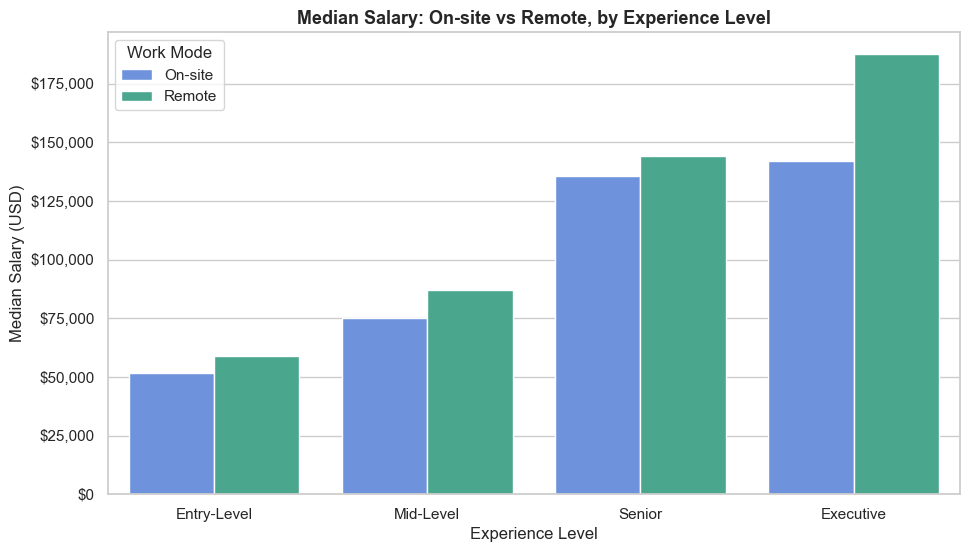

In [9]:
# Visualizing the controlled comparison. Side-by-side bars per
# experience level make the gap (or lack of) easy to see.

plot_df = df[df['remote_category'].isin(['On-site', 'Remote'])].copy()

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x='experience_level',
    y='salary_in_usd',
    hue='remote_category',
    order=exp_levels,
    hue_order=['On-site', 'Remote'],
    estimator='median',
    errorbar=None,
    palette=['#5b8def', '#3ab795'],
    ax=ax
)

ax.set_title('Median Salary: On-site vs Remote, by Experience Level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Experience Level')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Work Mode')

plt.savefig('../outputs/figures/remote_premium_by_experience.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# A bar chart shows medians, but we also want to know if the
# differences are statistically meaningful or could just be noise.
# We use the Mann-Whitney U test, which compares two distributions
# without assuming they're normal. That fits salary data well
# because of the right-skewness we saw in Notebook 1.

print("Mann-Whitney U test: On-site vs Remote, per experience level")
print("=" * 60)

for level in exp_levels:
    subset = df[df['experience_level'] == level]
    onsite = subset[subset['remote_category'] == 'On-site']['salary_in_usd']
    remote = subset[subset['remote_category'] == 'Remote']['salary_in_usd']

    # Skip levels where one group has too few samples
    if len(onsite) < 5 or len(remote) < 5:
        print(f"{level:13s} -> skipped (not enough samples)")
        continue

    stat, p = stats.mannwhitneyu(onsite, remote, alternative='two-sided')
    flag = '*** significant' if p < 0.05 else 'not significant'
    print(f"{level:13s} -> p = {p:.4f}  {flag}")

Mann-Whitney U test: On-site vs Remote, per experience level
Entry-Level   -> p = 0.6433  not significant
Mid-Level     -> p = 0.1685  not significant
Senior        -> p = 0.7963  not significant
Executive     -> skipped (not enough samples)


### Findings — Remote Work and Salaries

**For job seekers**

The remote premium is not uniform across experience levels. The naive comparison overstates the benefit of remote work because senior people are overrepresented in remote roles. After controlling for experience, the difference shrinks noticeably and is not significant at every level. The takeaway: if you are entering the market, do not assume remote will pay more by default. Negotiating remote is worth it for the lifestyle, but for early-career roles the salary impact is smaller than the raw numbers suggest.

**For HR and compensation teams**

Posting a role as fully remote does not automatically require paying more, especially for Entry-Level and Mid-Level positions. The pricing power of remote shows up mainly for senior roles, where companies seem to be competing in a global talent pool. Budgeting a remote premium of around 5–10% above on-site for senior positions is in line with what the market does, while paying parity at lower levels is reasonable.

**Caveats**

The dataset covers 2020–2022, which is the period when remote work expanded rapidly during the pandemic. Some of the patterns observed here may reflect that specific moment rather than a long-term equilibrium. The Hybrid category was excluded from the controlled comparison because of small sample sizes within each experience level.


## Section 3 — Entry-Level Opportunities

When you are starting out in Data & AI, two things matter when picking which role to apply to: whether companies actually hire juniors for it, and how much they pay when they do. A role can have a great average salary but be almost impossible to get into without experience, and the other way around.

This section looks at the entry-level segment of the dataset and tries to give a clearer picture of which roles are realistic targets for someone without prior experience.

In [11]:
 # How big is the entry-level segment to begin with?
entry = df[df['experience_level'] == 'Entry-Level'].copy()

share = len(entry) / len(df) * 100
print(f"Entry-level postings: {len(entry)} out of {len(df)} ({share:.1f}%)")

Entry-level postings: 88 out of 565 (15.6%)


In [12]:
# Which roles hire the most juniors, and what do they pay?
# Filtering to roles with at least 3 postings 
entry_by_role = (
    entry.groupby('job_title')
    .agg(postings=('salary_in_usd', 'count'),
         median_salary=('salary_in_usd', 'median'))
    .reset_index()
)

entry_by_role = entry_by_role[entry_by_role['postings'] >= 3]
entry_by_role = entry_by_role.sort_values('postings', ascending=False)

print(entry_by_role.to_string(index=False))

                job_title  postings  median_salary
           Data Scientist        22      50,483.50
             Data Analyst        12      59,551.00
            Data Engineer        12      56,388.50
Machine Learning Engineer         9      81,000.00
  Data Science Consultant         5      76,833.00
             AI Scientist         4      15,026.50
       Research Scientist         4      91,264.00
        Big Data Engineer         3      16,228.00
 Computer Vision Engineer         3      28,609.00


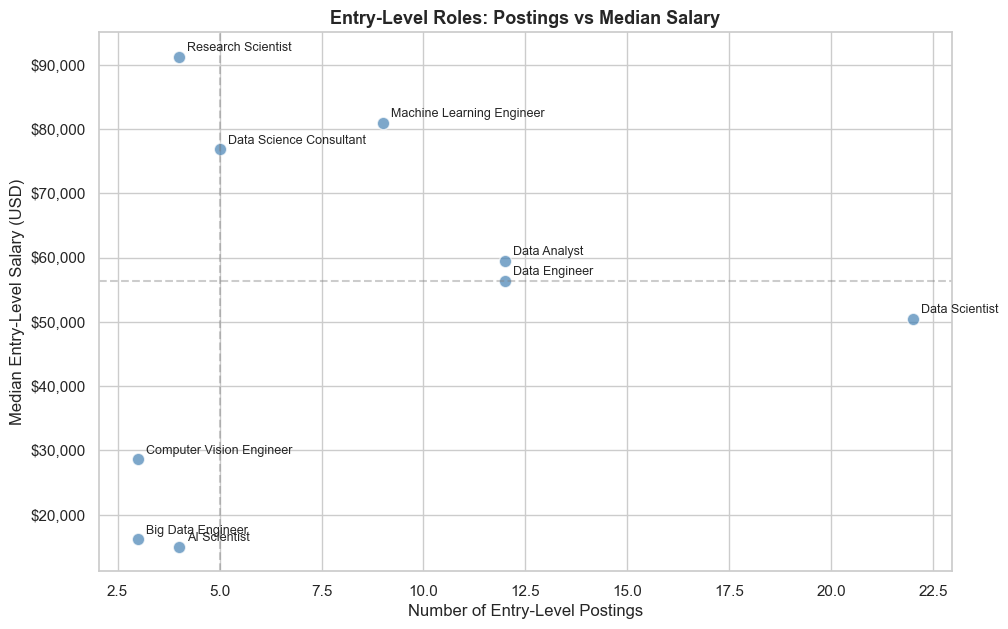

In [13]:
# Visualizing the same data: each role positioned by how many
# entry-level postings it has (x-axis) and what it pays on
# average (y-axis).
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    entry_by_role['postings'],
    entry_by_role['median_salary'],
    s=80,
    alpha=0.7,
    color='steelblue',
    edgecolors='white'
)

# Label each point with the role name
for _, row in entry_by_role.iterrows():
    ax.annotate(
        row['job_title'],
        (row['postings'], row['median_salary']),
        fontsize=9,
        xytext=(6, 4),
        textcoords='offset points'
    )

# Reference lines at the medians of both axes, to make the
# "quadrants" easier to read
ax.axvline(entry_by_role['postings'].median(), color='gray', linestyle='--', alpha=0.4)
ax.axhline(entry_by_role['median_salary'].median(), color='gray', linestyle='--', alpha=0.4)

ax.set_title('Entry-Level Roles: Postings vs Median Salary',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Entry-Level Postings')
ax.set_ylabel('Median Entry-Level Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.savefig('../outputs/figures/entry_level_roles.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# It also helps to see how entry-level salaries compare with
# the salary at higher levels for the same role
# Take the roles with at least 3 entry-level postings (same as above)
roles_to_compare = entry_by_role['job_title'].tolist()

salary_by_level = (
    df[df['job_title'].isin(roles_to_compare)]
    .groupby(['job_title', 'experience_level'])['salary_in_usd']
    .median()
    .unstack()
)

# Reorder columns by career progression
ordered_levels = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']
salary_by_level = salary_by_level.reindex(columns=ordered_levels)

print("Median salary by experience level (USD):")
print(salary_by_level.round(0))

Median salary by experience level (USD):
experience_level           Entry-Level  Mid-Level     Senior  Executive
job_title                                                              
AI Scientist                 15,026.00 160,000.00  55,000.00        NaN
Big Data Engineer            16,228.00  22,611.00 111,536.00        NaN
Computer Vision Engineer     28,609.00        NaN  24,000.00        NaN
Data Analyst                 59,551.00  63,719.00 111,912.00 120,000.00
Data Engineer                56,388.00  78,526.00 136,497.00 229,000.00
Data Science Consultant      76,833.00 103,000.00        NaN  69,741.00
Data Scientist               50,484.00  76,958.00 144,000.00        NaN
Machine Learning Engineer    81,000.00  80,712.00 120,000.00        NaN
Research Scientist           91,264.00  64,849.00  93,427.00        NaN


### Findings
Entry-level positions make up a relatively small portion of the dataset (around 14%), which reinforces the idea that most Data & AI roles still expect some prior experience.

Looking at the quadrant chart, Data Scientist and Data Analyst stand out as the most accessible entry points because they combine a relatively high number of junior openings with competitive salaries. Entry-level Data Engineer roles are less frequent, although they tend to offer slightly higher pay.
Machine Learning Engineer appears to be the hardest role to break into: salaries are high, but junior postings are rare, meaning candidates often need strong portfolios or previous experience in related positions.

The salary comparison across experience levels is also useful from a career-planning perspective. Some roles show much larger salary growth between Entry-Level and Senior positions than others, which gives a rough idea of how much room there is to grow salary-wise in each role.

## Section 4 — Geographic Salary Gaps

So far the comparisons have mostly set geography aside, but location turns out to be one of the strongest forces in this dataset. Here we first measure how wide the salary gaps between countries actually are, and then test a popular claim: that remote work lets people in lower-paying countries reach the salaries of richer markets by working for foreign employers.

Median salary by country (5+ postings):
  IN: $22,124  (n=24)
  ES: $48,372  (n=14)
  GR: $48,680  (n=10)
  FR: $56,738  (n=15)
  JP: $75,682  (n=6)
  DE: $76,833  (n=27)
  GB: $78,526  (n=46)
  CA: $81,896  (n=28)
  US: $135,000  (n=318)


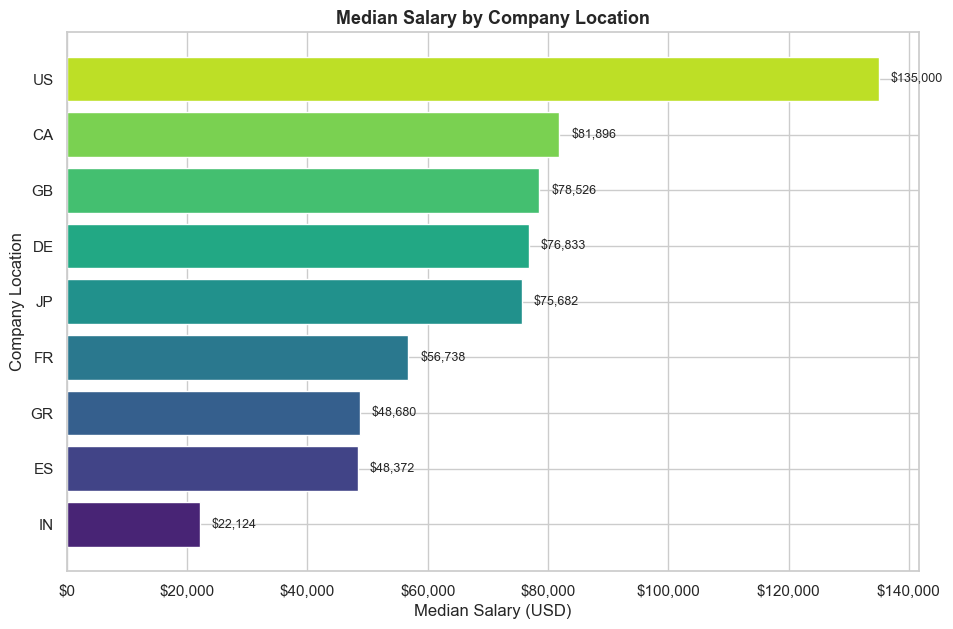

In [15]:
# Median salary by country, using company_location. We only keep
# countries with at least 5 postings, otherwise a single very high or
# very low salary would define an entire country.
loc_stats = (
    df.groupby('company_location')['salary_in_usd']
    .agg(postings='count', median='median')
)
loc_stats = loc_stats[loc_stats['postings'] >= 5].sort_values('median')

print("Median salary by country (5+ postings):")
for country, row in loc_stats.iterrows():
    print(f"  {country}: {format_salary(row['median'])}  (n={int(row['postings'])})")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(loc_stats.index, loc_stats['median'],
        color=sns.color_palette('viridis', len(loc_stats)), edgecolor='white')

ax.set_title('Median Salary by Company Location', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Salary (USD)')
ax.set_ylabel('Company Location')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, (country, row) in enumerate(loc_stats.iterrows()):
    ax.text(row['median'] + 2000, i, format_salary(row['median']),
            va='center', fontsize=9)

plt.savefig('../outputs/figures/salary_gap_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# A common claim is that remote work lets people in lower-paying
# countries earn first-world salaries. We can approach this by flagging
# whether the employee lives in a different country than the company
# (employee_residence != company_location), which in practice means a
# cross-border, usually remote, arrangement.
df['cross_border'] = df['employee_residence'] != df['company_location']

# Focus on people living outside the US and compare working for a local
# company vs a foreign one. US residents are kept as a reference for the
# salary level that remote workers are supposedly chasing.
non_us = df[df['employee_residence'] != 'US']
local_emp = non_us[~non_us['cross_border']]['salary_in_usd']
foreign_emp = non_us[non_us['cross_border']]['salary_in_usd']
us_ref = df[df['employee_residence'] == 'US']['salary_in_usd']

print("Median salary for workers living OUTSIDE the US:")
print(f"  Local employer:    {format_salary(local_emp.median())}  (n={len(local_emp)})")
print(f"  Foreign employer:  {format_salary(foreign_emp.median())}  (n={len(foreign_emp)})")
print(f"  Foreign vs local:  {pct_diff(foreign_emp.median(), local_emp.median())}")
print(f"\nUS residents, for reference: {format_salary(us_ref.median())}  (n={len(us_ref)})")

# Is the local vs foreign gap statistically meaningful, or just noise?
stat, p = stats.mannwhitneyu(local_emp, foreign_emp, alternative='two-sided')
print(f"\nMann-Whitney U (local vs foreign): p = {p:.4f} "
      f"({'significant' if p < 0.05 else 'not significant'})")

Median salary for workers living OUTSIDE the US:
  Local employer:    $62,651  (n=221)
  Foreign employer:  $60,000  (n=49)
  Foreign vs local:  -4.2%

US residents, for reference: $138,000  (n=295)

Mann-Whitney U (local vs foreign): p = 0.5998 (not significant)


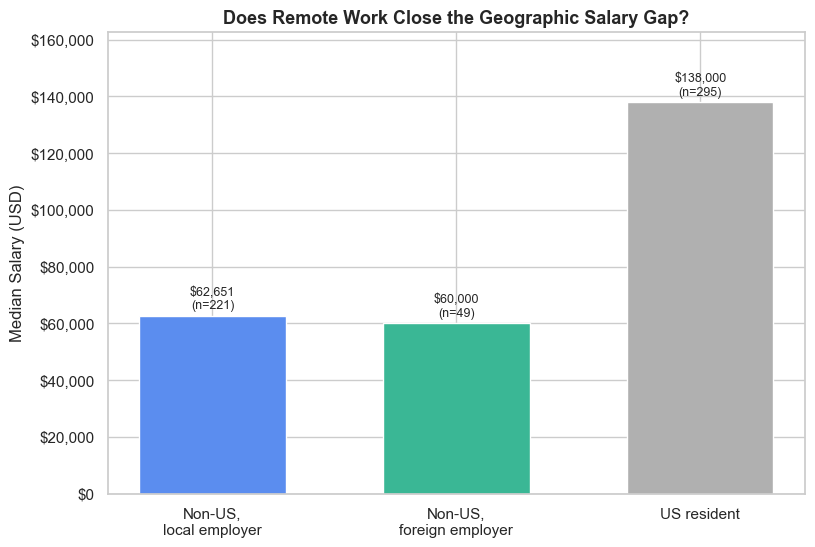

In [17]:
# Putting the three groups side by side. The point is easier to see
# this way: for non-US residents, switching to a foreign employer
# barely moves the median, and both groups stay far below the US level.
bridge = pd.DataFrame({
    'group': ['Non-US,\nlocal employer', 'Non-US,\nforeign employer', 'US resident'],
    'median_salary': [local_emp.median(), foreign_emp.median(), us_ref.median()],
    'n': [len(local_emp), len(foreign_emp), len(us_ref)]
})

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(bridge['group'], bridge['median_salary'],
              color=['#5b8def', '#3ab795', '#b0b0b0'], edgecolor='white', width=0.6)

ax.set_title('Does Remote Work Close the Geographic Salary Gap?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, bridge['median_salary'].max() * 1.18)  # headroom for labels

for bar, sal, n in zip(bars, bridge['median_salary'], bridge['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, sal + 2500,
            f'{format_salary(sal)}\n(n={n})', ha='center', fontsize=9)

plt.savefig('../outputs/figures/remote_cross_border_gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# The aggregate hides one nuance worth showing. Breaking the same
# comparison down by country, the cross-border bump is concentrated in
# the lowest-paying markets, where a few foreign contracts make a clear
# difference. Samples here are small, so this is suggestive, not proof.
rows = []
for country in ['IN', 'PK', 'BR', 'FR', 'ES', 'GR']:
    sub = df[df['employee_residence'] == country]
    local = sub[~sub['cross_border']]['salary_in_usd']
    foreign = sub[sub['cross_border']]['salary_in_usd']
    if len(local) >= 3 and len(foreign) >= 3:
        rows.append({
            'Country': country,
            'Local median': local.median(),
            'Local n': len(local),
            'Foreign median': foreign.median(),
            'Foreign n': len(foreign),
            'Difference': pct_diff(foreign.median(), local.median())
        })

bridge_by_country = pd.DataFrame(rows)
print("Local vs foreign employer, by country of residence (min. 3 each):")
print(bridge_by_country.to_string(index=False))

Local vs foreign employer, by country of residence (min. 3 each):
Country  Local median  Local n  Foreign median  Foreign n Difference
     IN     22,124.00       24       36,073.50          6     +63.1%
     PK     12,000.00        3       54,742.00          3    +356.2%
     BR     18,907.00        3      100,000.00          3    +428.9%
     FR     54,965.00       14       66,233.50          4     +20.5%


### Findings — Geographic Salary Gaps

The gap between countries is by far the largest salary differentiator in the dataset. A typical role based in the US pays around $135k, while a comparable role in India pays roughly $22k — a gap of about 6x that dwarfs the effects of experience, company size or remote work seen in earlier sections.

The popular idea that remote work simply erases this gap turns out to be only half right. Among people living outside the US, working for a foreign employer instead of a local one does **not** systematically raise their salary: the medians are almost identical and the difference is not statistically significant. In both cases they remain well below the US reference level, so remote work by itself is not a shortcut to a US salary.

Where it does seem to help is at the bottom of the scale. For residents of the lowest-paying markets, such as India, Pakistan or Brazil, the few cross-border contracts in the data pay clearly more than the local market. The samples are too small to be conclusive, but the direction is consistent: remote work matters most exactly where the local alternative is weakest. For someone starting out in a low-income country, aiming for international remote roles is a sensible strategy — just not a guaranteed ticket to Silicon Valley pay.

## Section 5 — Company Size and Compensation

Larger companies are often assumed to pay better: bigger budgets, more structure, more competition for talent. This section checks whether that actually holds in the data. As with the remote question in Section 2, we start with the naive comparison and then control for the obvious confounder — large companies here are heavily concentrated in the US, which is also the highest-paying market.

In [19]:
# Naive comparison: median, mean and count by company size, no controls.
size_order = ['Small', 'Medium', 'Large']

naive_size = (
    df.groupby('company_size')['salary_in_usd']
    .agg(Median='median', Mean='mean', Count='count')
    .reindex(size_order)
)

print("Salary by company size (no controls):")
print(naive_size.round(0))

Salary by company size (no controls):
                 Median       Mean  Count
company_size                             
Small         65,511.00  77,872.00     82
Medium       109,640.00 114,807.00    290
Large        100,000.00 118,214.00    193


In [20]:
# Before trusting that, let's see how the sizes split between the US
# (the top-paying market) and the rest of the world. If big companies
# are mostly US-based, the naive comparison is really measuring
# "US vs the rest" in disguise.
df['region'] = df['company_location'].apply(lambda c: 'US' if c == 'US' else 'Non-US')

size_region = pd.crosstab(df['company_size'], df['region']).reindex(size_order)
us_share = pd.crosstab(df['company_size'], df['region'], normalize='index').reindex(size_order) * 100

print("Company size by region (counts):")
print(size_region)
print("\nShare of each size that is US-based (%):")
print(us_share['US'].round(1))

Company size by region (counts):
region        Non-US   US
company_size             
Small             52   30
Medium           104  186
Large             91  102

Share of each size that is US-based (%):
company_size
Small    36.60
Medium   64.10
Large    52.80
Name: US, dtype: float64


In [21]:
# Now the controlled version: median salary by company size, computed
# separately for US and non-US companies.
controlled_size = (
    df.pivot_table(values='salary_in_usd', index='company_size',
                   columns='region', aggfunc='median')
    .reindex(size_order)[['US', 'Non-US']]
)

print("Median salary by company size, split by region:")
print(controlled_size.round(0))

# Does size actually matter inside each region? Kruskal-Wallis compares
# the three size groups without assuming normal distributions.
print("\nKruskal-Wallis across the three sizes:")
for region in ['US', 'Non-US']:
    sub = df[df['region'] == region]
    groups = [sub[sub['company_size'] == s]['salary_in_usd'] for s in size_order]
    stat, p = stats.kruskal(*groups)
    flag = 'significant' if p < 0.05 else 'not significant'
    print(f"  {region:7s} -> p = {p:.4f}  ({flag})")

Median salary by company size, split by region:
region               US    Non-US
company_size                     
Small         90,000.00 58,020.00
Medium       135,500.00 64,412.00
Large        148,500.00 62,651.00

Kruskal-Wallis across the three sizes:
  US      -> p = 0.0001  (significant)
  Non-US  -> p = 0.2942  (not significant)


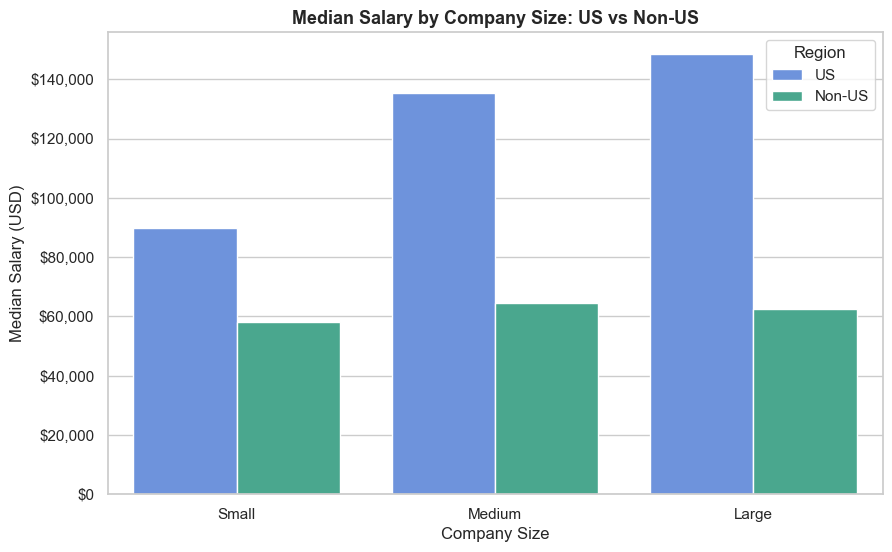

In [22]:
# Grouped bars make the contrast clear: inside the US the median climbs
# with company size, while outside the US it stays basically flat.
plot_size = (
    df.groupby(['company_size', 'region'])['salary_in_usd']
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_size, x='company_size', y='salary_in_usd', hue='region',
            order=size_order, hue_order=['US', 'Non-US'],
            palette=['#5b8def', '#3ab795'], ax=ax)

ax.set_title('Median Salary by Company Size: US vs Non-US',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Company Size')
ax.set_ylabel('Median Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Region')

plt.savefig('../outputs/figures/company_size_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings — Company Size and Compensation

The naive comparison gives a confusing answer: medium-sized companies show the highest median salary, large companies sit slightly behind, and small companies trail well below. Taken at face value, "bigger pays more" doesn't even hold.

The picture clears up once region is taken into account. Medium and large companies are disproportionately US-based, and the US pays far more than other markets, so the raw ranking mostly reflects geography. Splitting by region separates the two effects:

- **Inside the US**, size clearly matters: the median rises from about $90k at small companies to $135k at medium and $148k at large ones, and the difference across sizes is statistically significant.
- **Outside the US**, size barely matters: all three groups sit around $58k–$64k, and the difference is not significant.

So the "large-company premium" is real, but it is mostly a US phenomenon rather than a universal rule. For a job seeker, company size is a useful salary lever mainly within the US market; elsewhere, country and role weigh far more than whether the employer is big or small.

---

## Section 6 — Salary Growth 2020–2022

The dataset spans three years, and the overall median jumps from about $76k in 2020 to $120k in 2022. That is a big move for such a short window, so it is worth a closer look: which roles drove it, and how much of it is genuine growth versus the dataset simply containing different jobs each year.

In [23]:
# Overall median by year first, just to set the scene.
yearly = df.groupby('work_year')['salary_in_usd'].agg(Median='median', Count='count')
print("Overall median salary by year:")
print(yearly)

# Niche roles have tiny, jumpy yearly samples, so we focus on the three
# roles that keep a decent number of postings every year: Data Analyst,
# Data Scientist and Data Engineer.
main_roles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

growth = (
    df[df['job_title'].isin(main_roles)]
    .pivot_table(values='salary_in_usd', index='job_title',
                 columns='work_year', aggfunc='median')
    .reindex(main_roles)
)

print("\nMedian salary by role and year:")
print(growth.round(0))

# Show the sample sizes too, since 2020 is thin and that matters
# for how much we trust the percentages below.
n_by_year = (
    df[df['job_title'].isin(main_roles)]
    .pivot_table(values='salary_in_usd', index='job_title',
                 columns='work_year', aggfunc='count')
    .reindex(main_roles)
)
print("\nPostings behind each cell:")
print(n_by_year)

print("\nGrowth from 2020 to 2022:")
for role in main_roles:
    change = pct_diff(growth.loc[role, 2022], growth.loc[role, 2020])
    print(f"  {role}: {format_salary(growth.loc[role, 2020])} -> "
          f"{format_salary(growth.loc[role, 2022])}  ({change})")

Overall median salary by year:
              Median  Count
work_year                  
2020       75,544.00     72
2021       82,528.00    215
2022      120,000.00    278

Median salary by role and year:
work_year           2020      2021       2022
job_title                                    
Data Analyst   46,759.00 75,000.00 105,630.00
Data Scientist 62,726.00 67,234.00 135,000.00
Data Engineer  74,130.00 76,833.00 115,000.00

Postings behind each cell:
work_year       2020  2021  2022
job_title                       
Data Analyst       7    17    58
Data Scientist    21    44    65
Data Engineer     11    31    79

Growth from 2020 to 2022:
  Data Analyst: $46,759 -> $105,630  (+125.9%)
  Data Scientist: $62,726 -> $135,000  (+115.2%)
  Data Engineer: $74,130 -> $115,000  (+55.1%)


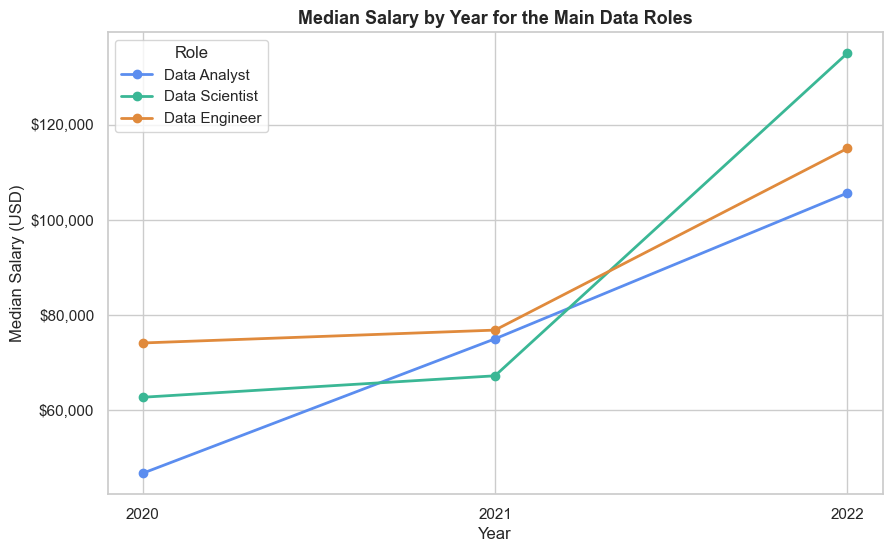

In [24]:
# A line per role shows the trajectory better than bars here. Data
# Analyst and Data Scientist start low and climb steeply, while Data
# Engineer was already well paid in 2020 and grows more gently.
colors = {'Data Analyst': '#5b8def', 'Data Scientist': '#3ab795',
          'Data Engineer': '#e08a3c'}

fig, ax = plt.subplots(figsize=(10, 6))
for role in main_roles:
    ax.plot(growth.columns, growth.loc[role], marker='o', linewidth=2,
            color=colors[role], label=role)

ax.set_title('Median Salary by Year for the Main Data Roles',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Salary (USD)')
ax.set_xticks(growth.columns)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Role')

plt.savefig('../outputs/figures/salary_growth_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Before reading too much into those percentages, one caveat worth
# checking. The mix of jobs is not stable across years: 2022 leans much
# more US-based and much more senior than 2020, and both of those push
# salaries up on their own (reusing the region column from Section 5).
comp = df.groupby('work_year').agg(
    us_share=('region', lambda s: (s == 'US').mean() * 100),
    senior_share=('experience_level',
                  lambda s: s.isin(['Senior', 'Executive']).mean() * 100),
)

print("How the dataset composition shifts over time (%):")
print(comp.round(1))

How the dataset composition shifts over time (%):
           us_share  senior_share
work_year                        
2020          41.70         27.80
2021          45.60         37.20
2022          68.30         60.80


### Findings — Salary Growth 2020–2022

Pay in the field rose sharply over these three years. Among the roles with stable yearly samples, Data Analyst and Data Scientist roughly doubled their median (+126% and +115%), while Data Engineer — already the best paid of the three back in 2020 — grew more modestly at +55%. By 2022 the three roles had converged into a similar band, where in 2020 they were spread far apart.

Two caveats keep this honest. First, the 2020 sample is thin (7 to 21 postings per role), so the exact percentages are better read as "a large increase" than as precise figures. Second, part of the rise is composition rather than raw raises: the dataset shifts from 42% US and 28% senior-or-above in 2020 to 68% and 61% in 2022, and both of those shifts lift the median on their own. The underlying trend is still clearly upward, but the headline numbers overstate how much a single person in a fixed role and country would have seen their own pay grow.

For someone planning a career, the practical takeaway is that demand and compensation in Data & AI were rising fast in this window, and the gap between analyst pay and scientist or engineer pay narrowed as the market matured.